# Causal Inference for a Clinical Intervention

**Scenario.** A hospital network rolled out a new **care-coordination intervention** intended to cut **30-day readmissions**. It was *not* randomized: higher-risk patients, and better-resourced regions, were more likely to receive it. Our job is to estimate the **causal effect** on readmission despite this non-random assignment.

Because randomization isn't available, a naive treated-vs-untreated comparison is confounded. This notebook works through the quasi-experimental toolkit in the `causal` library and shows how each method recovers the true effect that the naive comparison misses.

> The data here are **simulated**, so we know the ground truth and can check each estimator against it. The patient-level intervention truly **reduces** readmission by 5 percentage points; the region-level rollout reduces it by 8.

## 1 — Setup and motivation: why the naive comparison fails

We start with patient-level observational data. Disease **severity** drives *both* the chance of receiving the intervention *and* the readmission risk — the textbook definition of **confounding by indication**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from causal.data.simulate import simulate_observational, simulate_panel

TRUE_PATIENT_EFFECT = -0.05  # known because the data are simulated
patients = simulate_observational(n=6000, treatment_effect=TRUE_PATIENT_EFFECT,
                                  confounding_strength=2.0, seed=7)
patients.head()

,age,severity,comorbidities,treatment,outcome
0,60.018452,2.740017,3.0,0,0
1,64.481183,5.350245,2.0,1,0
2,55.887932,9.107262,1.0,1,0
3,46.641122,2.147589,0.0,0,0
4,53.179938,6.237894,2.0,0,0


In [2]:
def naive_diff(df):
    return df.loc[df.treatment == 1, 'outcome'].mean() - df.loc[df.treatment == 0, 'outcome'].mean()

print(f"True effect (simulated):         {TRUE_PATIENT_EFFECT:+.4f}  (intervention REDUCES readmission)")
print(f"Naive treated - control:         {naive_diff(patients):+.4f}  (looks neutral / harmful!)")
print()
print("Mean severity by group (the confounder):")
print(patients.groupby('treatment')['severity'].mean().round(2))

True effect (simulated):         -0.0500  (intervention REDUCES readmission)
Naive treated - control:         +0.0170  (looks neutral / harmful!)

Mean severity by group (the confounder):
treatment
0    3.85
1    6.17
Name: severity, dtype: float64


The naive difference is **positive** — it suggests the intervention does nothing, or even *increases* readmission. That's the confounding talking: treated patients are substantially sicker (higher severity), so they would have had more readmissions anyway. The plots below make the imbalance visible.

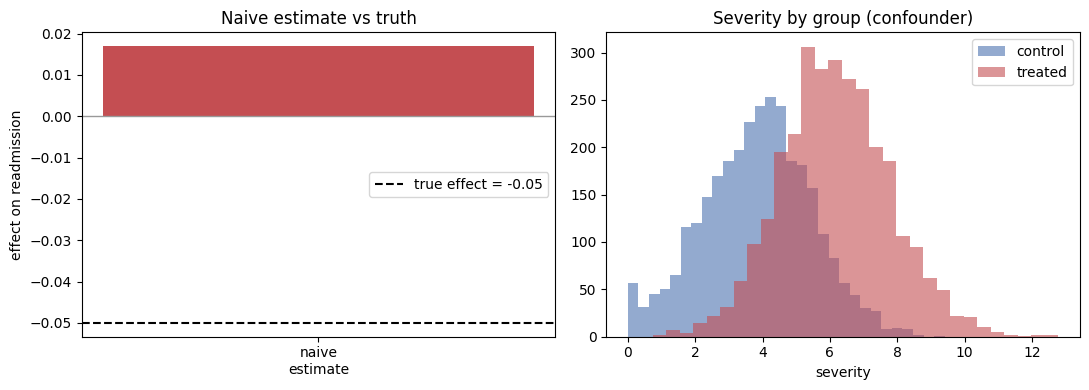

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(['naive\nestimate'], [naive_diff(patients)], color='#c44e52')
axes[0].axhline(TRUE_PATIENT_EFFECT, color='k', ls='--', label=f'true effect = {TRUE_PATIENT_EFFECT}')
axes[0].axhline(0, color='0.6', lw=1)
axes[0].set_title('Naive estimate vs truth'); axes[0].set_ylabel('effect on readmission'); axes[0].legend()

for t, c in [(0, '#4c72b0'), (1, '#c44e52')]:
    axes[1].hist(patients.loc[patients.treatment == t, 'severity'], bins=30, alpha=0.6,
                 color=c, label=('treated' if t else 'control'))
axes[1].set_title('Severity by group (confounder)'); axes[1].set_xlabel('severity'); axes[1].legend()
fig.tight_layout(); plt.show()

**Identification strategy.** With rich pre-treatment covariates we can adjust for measured confounding using **propensity-score matching** and **inverse-probability weighting** (Sections 2-3). For the region-level rollout we exploit the panel structure with **difference-in-differences** and **synthetic control** (Sections 4-5). Finally we stress-test the key assumption — no *unmeasured* confounding — with **sensitivity analysis** (Section 6).

## 2 — Propensity score matching

Estimate each patient's probability of treatment from covariates, then match treated patients to similar controls. First check **overlap** (common support): the score distributions must overlap for matching to be possible.

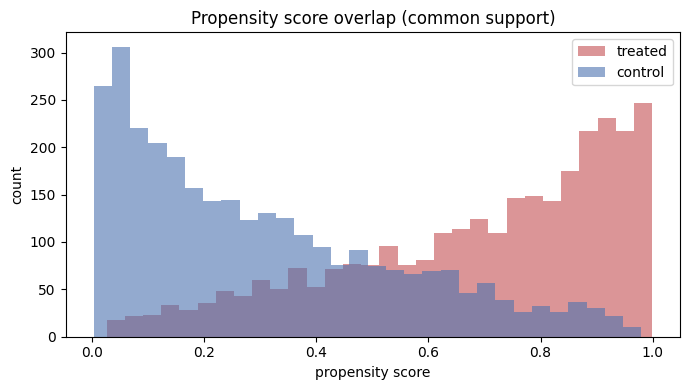

In [4]:
from causal.matching import (PropensityScoreModel, PropensityScoreMatching,
                              InverseProbabilityWeighting, plot_balance)

covariates = patients[['age', 'severity', 'comorbidities']]
treatment, outcome = patients['treatment'], patients['outcome']

ps_model = PropensityScoreModel(covariates, treatment).fit()
ps_model.plot_overlap(); plt.show()

Method:   Propensity score matching (ATT)
Estimate: -0.0599 (SE 0.0145)
95% CI:   [-0.0883, -0.0315]
p-value:  3.609e-05
N:        1352 treated, 1352 control
Assumptions:
  - Conditional ignorability (no unmeasured confounders)
  - Common support / overlap between treated and control
  - Correctly specified propensity model

Matched 1352/2947 treated patients (unmatched 1595)


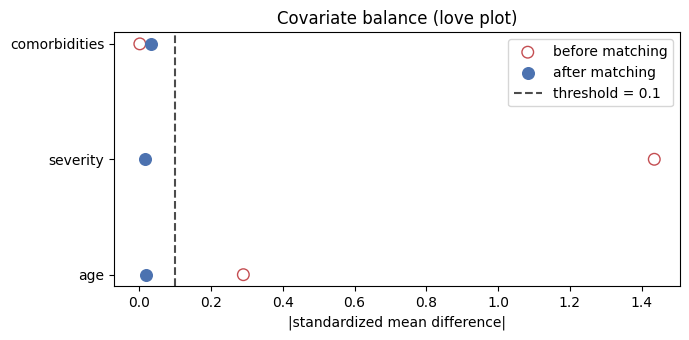

In [5]:
psm = PropensityScoreMatching(covariates, treatment, outcome, caliper=0.05)
match = psm.match()
att = psm.estimate_att()

print(att.summary())
print(f"\nMatched {match.n_matched}/{match.n_treated} treated patients "
      f"(unmatched {match.n_unmatched})")

plot_balance(match); plt.show()

The love plot shows every covariate's standardized mean difference dropping below the 0.1 balance threshold after matching — severity in particular goes from badly imbalanced to negligible. On the balanced sample the **ATT is negative**: the intervention reduces readmission, recovering the truth the naive comparison hid.

## 3 — IPW as a robustness check

Inverse-probability weighting reweights the whole sample so covariates balance, using a different modelling path than matching. Agreement between the two is reassuring; the weight distribution flags any extreme weights (poor overlap).

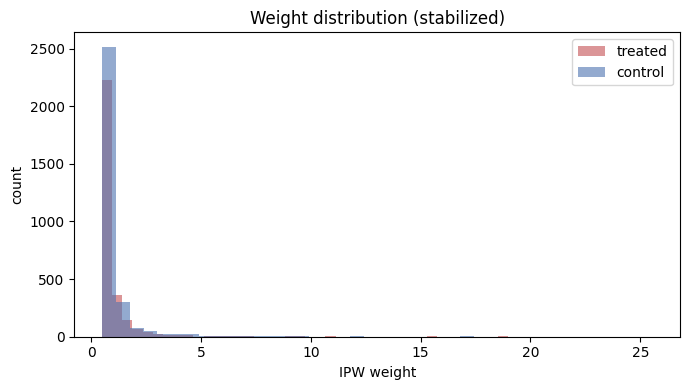

Effect on 30-day readmission (truth = -0.0500):
  naive    : +0.0170   <- confounded
  PSM (ATT): -0.0599   CI [-0.0883, -0.0315]
  IPW (ATE): -0.0549   CI [-0.0820, -0.0278]


In [6]:
ipw = InverseProbabilityWeighting(covariates, treatment, outcome)
ate = ipw.estimate_ate(stabilized=True)
ipw.plot_weight_distribution(); plt.show()

print('Effect on 30-day readmission (truth = -0.0500):')
print(f"  naive    : {naive_diff(patients):+.4f}   <- confounded")
print(f"  PSM (ATT): {att.estimate:+.4f}   CI [{att.confidence_interval[0]:+.4f}, {att.confidence_interval[1]:+.4f}]")
print(f"  IPW (ATE): {ate.estimate:+.4f}   CI [{ate.confidence_interval[0]:+.4f}, {ate.confidence_interval[1]:+.4f}]")

## 4 — Difference-in-Differences for the regional rollout

The intervention was also adopted by a group of **regions** at a known time. With repeated measurements per region we can use DiD, comparing the *change* in readmission for adopting vs non-adopting regions. The identifying assumption is **parallel trends** — verified visually and with a differential-slope test before trusting the estimate.

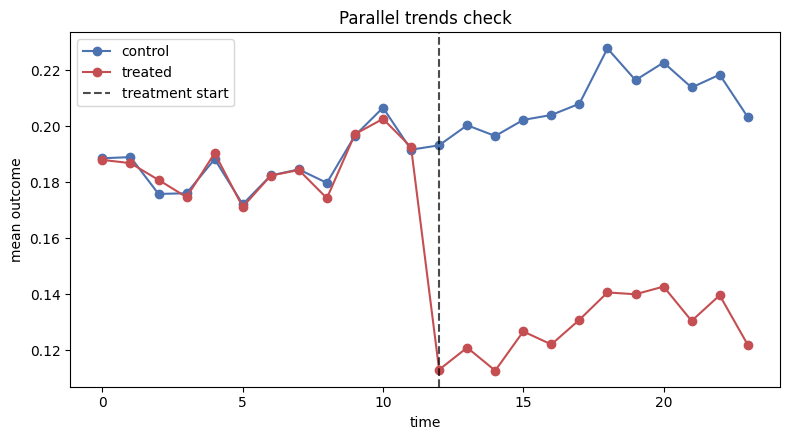

Fail to reject parallel trends (F=0.50, p=0.484). Pre-treatment trends are statistically indistinguishable; the DiD assumption is supported.


In [7]:
from causal.did import DifferenceInDifferences

regions = simulate_panel(n_units=40, n_periods=24, treatment_period=12,
                         treatment_effect=-0.08, n_treated_units=10, seed=7)
did = DifferenceInDifferences(regions, 'unit', 'time', 'outcome', 'treatment', treatment_time=12)

did.plot_parallel_trends(); plt.show()
print(did.test_parallel_trends().interpretation)

Method:   Difference-in-differences (ATT)
Estimate: -0.0799 (SE 0.0012)
95% CI:   [-0.0823, -0.0775]
p-value:  0
N:        10 treated, 30 control
Assumptions:
  - Parallel trends: absent treatment, treated and control move together
  - No anticipation of treatment before treatment_time
  - Stable composition of treated/control groups over time


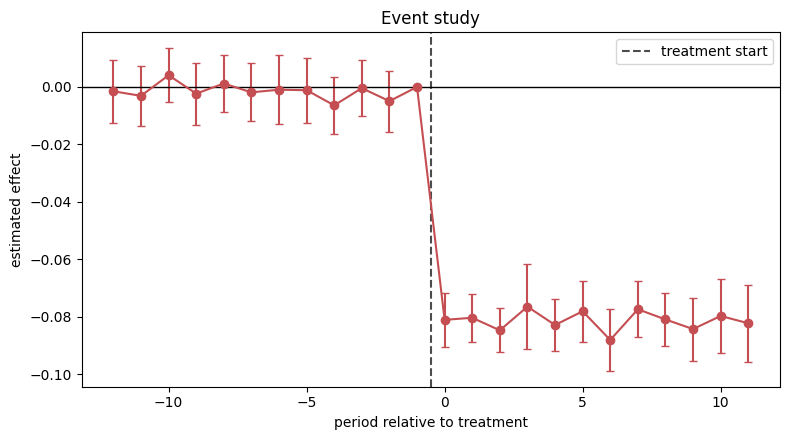

In [8]:
did_est = did.estimate()
print(did_est.summary())

# Event study: leads ~0 (parallel trends), lags settle at the treatment effect.
did.event_study(); plt.show()

## 5 — Synthetic control for a single flagship region

To evaluate **one** region on its own, DiD lacks power. Synthetic control builds a weighted blend of donor regions that tracks the treated region pre-treatment; the post-treatment gap is the effect. Inference comes from **placebo tests** — re-running the method on each donor as if it were treated.

Pre-treatment RMSPE : 0.0070  (low = good pre-period fit)
Synthetic control ATT: -0.0816  (truth -0.0800)


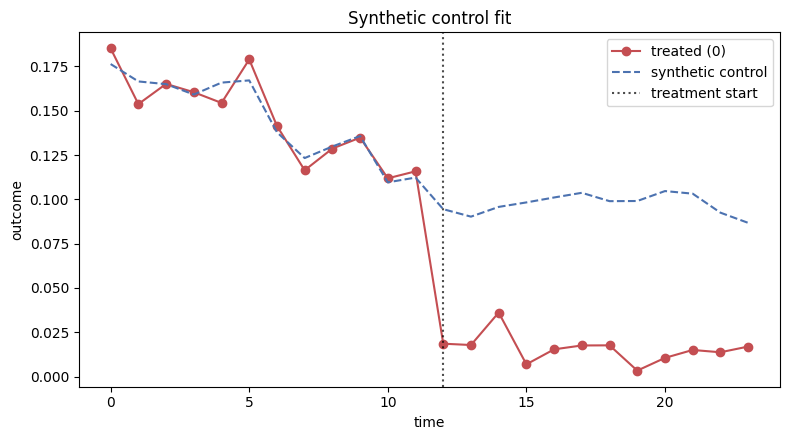

In [9]:
from causal.synthetic_control import SyntheticControl

flagship = simulate_panel(n_units=20, n_periods=24, treatment_unit=0, treatment_period=12,
                          treatment_effect=-0.08, n_treated_units=1, seed=7)
sc = SyntheticControl(flagship, 'unit', 'time', 'outcome',
                      treated_unit=0, treatment_time=12).fit()

print(f"Pre-treatment RMSPE : {sc.pre_treatment_fit():.4f}  (low = good pre-period fit)")
print(f"Synthetic control ATT: {sc.estimate().estimate:+.4f}  (truth -0.0800)")
sc.plot(); plt.show()

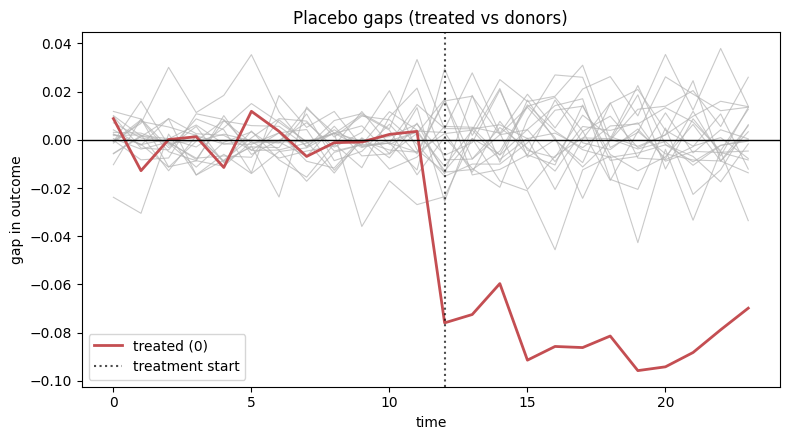

Treated post/pre RMSPE ratio: 11.7
Placebo p-value            : 0.050


In [10]:
placebo = sc.placebo_tests(); plt.show()
print(f"Treated post/pre RMSPE ratio: {placebo.treated_post_rmspe_ratio:.1f}")
print(f"Placebo p-value            : {placebo.p_value:.3f}")

## 6 — Sensitivity analysis: what about *unmeasured* confounding?

Every method so far assumes we measured all confounders. We can't prove that, but we can quantify how strong a hidden confounder would have to be to overturn the matched result.

In [11]:
from causal.sensitivity import e_value, rosenbaum_bounds, plot_sensitivity_curve

m = match.matched_data
p_treated = m.loc[m.treatment == 1, 'outcome'].mean()
p_control = m.loc[m.treatment == 0, 'outcome'].mean()
n_t = int((m.treatment == 1).sum()); n_c = int((m.treatment == 0).sum())
se_logrr = np.sqrt((1 - p_treated) / (p_treated * n_t) + (1 - p_control) / (p_control * n_c))
ev = e_value(np.log(p_treated / p_control), se_logrr)

print(f"Matched risk ratio       : {ev.observed_risk_ratio:.2f}")
print(f"E-value (point estimate) : {ev.point_estimate_evalue:.2f}")
print(f"E-value (CI nearest null): {ev.confidence_interval_evalue:.2f}")

Matched risk ratio       : 0.71
E-value (point estimate) : 2.17
E-value (CI nearest null): 1.68


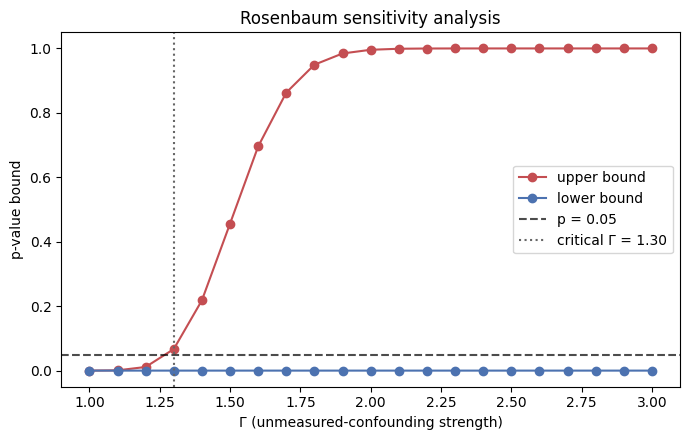

Critical Gamma: 1.3
An unmeasured confounder would need to raise the odds of treatment by ~1.3x between matched patients before the result loses significance.


In [12]:
rb = rosenbaum_bounds(m, outcome_col='outcome', treatment_col='treatment')
plot_sensitivity_curve(rb); plt.show()
print(f"Critical Gamma: {rb.critical_gamma}")
print(f"An unmeasured confounder would need to raise the odds of treatment by "
      f"~{rb.critical_gamma}x between matched patients before the result loses significance.")

**Reading it.** The E-value says an unmeasured confounder would need associations of that magnitude with *both* treatment and outcome — beyond the measured covariates — to fully explain away the effect. Combined with the consistent estimates across four independent methods, the conclusion that the intervention reduces readmission is reasonably robust.

## 7 — Summary: when to use which method

| Scenario | Recommended method |
|---|---|
| Many treated and control units, rich covariates | Propensity score matching or IPW |
| Panel data, multiple units, parallel trends plausible | Difference-in-differences |
| Single treated unit, multiple control units | Synthetic control |
| Assessing robustness to unmeasured confounding | Rosenbaum bounds / E-value |
| Randomization is feasible | Just run the RCT |

**Results across methods (truth: patient −0.05, region −0.08):**

| Method | Estimate | Inference |
|---|---|---|
| Naive comparison | *positive* | misleading (confounded) |
| Propensity score matching (ATT) | ≈ −0.06 | 95% CI excludes 0 |
| Inverse probability weighting (ATE) | ≈ −0.05 | 95% CI excludes 0 |
| Difference-in-differences (ATT) | ≈ −0.08 | clustered SEs, p < 0.001 |
| Synthetic control | ≈ −0.08 | placebo p ≈ 0.05 |

Four methods resting on **different assumptions** agree that the intervention reduces readmissions — exactly the triangulation that makes a causal claim credible without an RCT.

### References
- Rosenbaum & Rubin (1983). *The central role of the propensity score in observational studies for causal effects.* Biometrika.
- Abadie & Gardeazabal (2003). *The economic costs of conflict: A case study of the Basque Country.* American Economic Review. (synthetic control)
- VanderWeele & Ding (2017). *Sensitivity analysis in observational research: introducing the E-value.* Annals of Internal Medicine.
- Angrist & Pischke (2009). *Mostly Harmless Econometrics.* (difference-in-differences)